# Project FORESIGHT

## Notebook 5 — Demand Forecasting Model Development

### Business Context

The objective of Project FORESIGHT is to develop a machine learning-based demand forecasting system for retail sales.

Notebook 4 transformed historical transaction data into a forecasting-ready dataset containing calendar, lag, rolling, inventory, pricing, and promotion features.

This notebook uses those engineered features to train and evaluate machine learning models capable of predicting daily product demand.

### Objectives

This notebook will:

- Load the feature-engineered forecasting dataset
- Prepare the modeling dataset
- Define the forecasting target
- Create a time-based train-test split
- Establish a naive forecasting baseline
- Train a Random Forest model
- Train an XGBoost model
- Compare model performance
- Analyze feature importance
- Visualize actual versus predicted demand
- Generate business insights
- Save the best-performing model

In [1]:
# 1. Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import joblib

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# 2. Load Forecasting Dataset

The feature-engineered dataset produced in Notebook 4 is loaded for machine learning model development.

In [2]:
forecast_df = pd.read_csv(
    "/kaggle/input/datasets/shadabkazi18/project-foresight-feature-engineered-csv/forecast_feature_engineered (2).csv"
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
print("Shape:", forecast_df.shape)

forecast_df.head()

Shape: (873633, 27)


,date,store_id,sku_id,daily_quantity,daily_revenue,avg_price,avg_discount,transactions,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_std_7,rolling_mean_30,rolling_std_30,last_restock_date,stock_on_hand,reorder_point,stock_cover,low_stock_flag,price_per_unit,discount_rate,price_change,price_change_pct,promotion_flag,discount_category
0,2025-10-25,ST01,SKU00005,4,554.0,138.5,0.0,1,3.0,2.0,1.0,3.0,2.142857,1.069045,1.800000,1.186127,2025-11-07,15.0,91.0,7.000000,1,138.5,0.0,0.0,0.0,0,No Discount
1,2025-11-01,ST01,SKU00005,5,692.5,138.5,0.0,1,4.0,1.0,4.0,1.0,2.428571,1.272418,1.866667,1.252125,2025-11-07,15.0,91.0,6.176471,1,138.5,0.0,0.0,0.0,0,No Discount
2,2025-11-07,ST01,SKU00005,3,415.5,138.5,0.0,1,5.0,4.0,1.0,3.0,3.000000,1.414214,1.900000,1.322224,2025-11-07,15.0,91.0,5.000000,1,138.5,0.0,0.0,0.0,0,No Discount
3,2022-09-23,ST01,SKU00020,3,328.5,109.5,0.0,1,3.0,1.0,2.0,6.0,2.000000,0.816497,2.133333,1.252125,2025-10-06,0.0,37.0,0.000000,1,109.5,0.0,0.0,0.0,0,No Discount
4,2022-09-27,ST01,SKU00020,5,547.5,109.5,0.0,1,3.0,2.0,1.0,4.0,2.285714,0.755929,2.166667,1.261727,2025-10-06,0.0,37.0,0.000000,1,109.5,0.0,0.0,0.0,0,No Discount


In [4]:
forecast_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 873633 entries, 0 to 873632
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               873633 non-null  object 
 1   store_id           873633 non-null  object 
 2   sku_id             873633 non-null  object 
 3   daily_quantity     873633 non-null  int64  
 4   daily_revenue      873633 non-null  float64
 5   avg_price          873633 non-null  float64
 6   avg_discount       873633 non-null  float64
 7   transactions       873633 non-null  int64  
 8   lag_1              873633 non-null  float64
 9   lag_7              873633 non-null  float64
 10  lag_14             873633 non-null  float64
 11  lag_28             873633 non-null  float64
 12  rolling_mean_7     873633 non-null  float64
 13  rolling_std_7      873633 non-null  float64
 14  rolling_mean_30    873633 non-null  float64
 15  rolling_std_30     873633 non-null  float64
 16  la

# 3. Data Validation

Before modeling, the dataset is checked for duplicate records, missing values, and data types.

This ensures that the forecasting dataset is suitable for machine learning.

In [5]:
print("Duplicate rows:", forecast_df.duplicated().sum())

print("\nMissing values:")
print(
    forecast_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

Duplicate rows: 0

Missing values:
date                 0
store_id             0
sku_id               0
daily_quantity       0
daily_revenue        0
avg_price            0
avg_discount         0
transactions         0
lag_1                0
lag_7                0
lag_14               0
lag_28               0
rolling_mean_7       0
rolling_std_7        0
rolling_mean_30      0
rolling_std_30       0
last_restock_date    0
stock_on_hand        0
reorder_point        0
stock_cover          0
low_stock_flag       0
price_per_unit       0
discount_rate        0
price_change         0
price_change_pct     0
promotion_flag       0
discount_category    0
dtype: int64


In [6]:
print("Columns:")
print(forecast_df.columns.tolist())

Columns:
['date', 'store_id', 'sku_id', 'daily_quantity', 'daily_revenue', 'avg_price', 'avg_discount', 'transactions', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30', 'rolling_std_30', 'last_restock_date', 'stock_on_hand', 'reorder_point', 'stock_cover', 'low_stock_flag', 'price_per_unit', 'discount_rate', 'price_change', 'price_change_pct', 'promotion_flag', 'discount_category']


# 4. Prepare Forecasting Dataset

The dataset is sorted chronologically because forecasting models must learn from historical observations and predict future observations.

The target variable is daily_quantity, representing the quantity sold for a Store-SKU combination on a given day.

In [7]:
forecast_df["date"] = pd.to_datetime(
    forecast_df["date"]
)

forecast_df = forecast_df.sort_values(
    ["date", "store_id", "sku_id"]
).reset_index(drop=True)

print(
    "Date range:",
    forecast_df["date"].min(),
    "to",
    forecast_df["date"].max()
)

Date range: 2022-01-31 00:00:00 to 2025-12-31 00:00:00


# 5. Feature Selection

The target variable is daily_quantity.

Features that directly depend on the current day's demand, such as daily_revenue, are excluded to prevent target leakage.

Historical lag and rolling features are retained because they represent information available from previous observations.

In [8]:
target = "daily_quantity"

leakage_columns = [
    "daily_quantity",
    "daily_revenue",
    "date",
    "last_restock_date"
]

feature_columns = [
    column
    for column in forecast_df.columns
    if column not in leakage_columns
]

X = forecast_df[feature_columns].copy()
y = forecast_df[target].copy()

print("Target:", target)

print("\nNumber of features:", len(feature_columns))

print("\nFeatures:")
print(feature_columns)

Target: daily_quantity

Number of features: 23

Features:
['store_id', 'sku_id', 'avg_price', 'avg_discount', 'transactions', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30', 'rolling_std_30', 'stock_on_hand', 'reorder_point', 'stock_cover', 'low_stock_flag', 'price_per_unit', 'discount_rate', 'price_change', 'price_change_pct', 'promotion_flag', 'discount_category']


# 6. Time-Based Train-Test Split

A chronological split is used instead of a random split.

The first 80% of observations are used for training and the final 20% are reserved for testing.

This simulates the real-world forecasting scenario where historical data is used to predict future demand.

In [9]:
split_index = int(len(forecast_df) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

Training rows: 698906
Testing rows : 174727


In [10]:
print(
    "Training period:",
    forecast_df.iloc[0]["date"],
    "to",
    forecast_df.iloc[split_index - 1]["date"]
)

print(
    "Testing period:",
    forecast_df.iloc[split_index]["date"],
    "to",
    forecast_df.iloc[-1]["date"]
)

Training period: 2022-01-31 00:00:00 to 2025-07-02 00:00:00
Testing period: 2025-07-02 00:00:00 to 2025-12-31 00:00:00


# 7. Categorical Feature Encoding

Machine learning models require numerical input.

Categorical variables such as Store ID, SKU ID, and Discount Category are converted into numerical representations using OrdinalEncoder.

Unknown categories appearing in the test set are safely handled.

In [11]:
categorical_columns = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['store_id', 'sku_id', 'discount_category']


In [12]:
encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

if len(categorical_columns) > 0:

    X_train[categorical_columns] = encoder.fit_transform(
        X_train[categorical_columns].astype(str)
    )

    X_test[categorical_columns] = encoder.transform(
        X_test[categorical_columns].astype(str)
    )

print("Encoding completed successfully.")

Encoding completed successfully.


In [13]:
print(X_train.dtypes)

store_id             float64
sku_id               float64
avg_price            float64
avg_discount         float64
transactions           int64
lag_1                float64
lag_7                float64
lag_14               float64
lag_28               float64
rolling_mean_7       float64
rolling_std_7        float64
rolling_mean_30      float64
rolling_std_30       float64
stock_on_hand        float64
reorder_point        float64
stock_cover          float64
low_stock_flag         int64
price_per_unit       float64
discount_rate        float64
price_change         float64
price_change_pct     float64
promotion_flag         int64
discount_category    float64
dtype: object


In [14]:
print("Remaining object columns:")

print(
    X_train.select_dtypes(
        include=["object"]
    ).columns.tolist()
)

Remaining object columns:
[]


# 8. Baseline Forecast

A naive forecasting model is established as a benchmark.

The previous observed demand (`lag_1`) is used as the prediction for the next observation.

Machine learning models should outperform this baseline to demonstrate that the engineered features provide additional predictive value.

In [15]:
baseline_predictions = X_test["lag_1"].values

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print("Baseline Performance")
print("--------------------")
print(f"MAE : {baseline_mae:.3f}")
print(f"RMSE: {baseline_rmse:.3f}")
print(f"R²  : {baseline_r2:.3f}")

Baseline Performance
--------------------
MAE : 1.642
RMSE: 2.582
R²  : 0.433


# 9. Random Forest Model

Random Forest is used as the first machine learning forecasting model.

The algorithm combines multiple decision trees and can capture nonlinear relationships between demand and features such as historical sales, pricing, inventory, and seasonality.

In [16]:
rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [17]:
rf_predictions = rf_model.predict(
    X_test
)

print("Predictions generated:", len(rf_predictions))

Predictions generated: 174727


In [18]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Performance")
print("------------------------")
print(f"MAE : {rf_mae:.3f}")
print(f"RMSE: {rf_rmse:.3f}")
print(f"R²  : {rf_r2:.3f}")

Random Forest Performance
------------------------
MAE : 1.022
RMSE: 1.324
R²  : 0.851


# 10. XGBoost Model

XGBoost is a gradient boosting algorithm that builds decision trees sequentially to minimize prediction error.

It is well suited to structured retail datasets containing nonlinear relationships between historical demand, pricing, promotions, inventory, and calendar features.

In [19]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [20]:
xgb_predictions = xgb_model.predict(
    X_test
)

print("Predictions generated:", len(xgb_predictions))

Predictions generated: 174727


In [21]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)

print("XGBoost Performance")
print("-------------------")
print(f"MAE : {xgb_mae:.3f}")
print(f"RMSE: {xgb_rmse:.3f}")
print(f"R²  : {xgb_r2:.3f}")

XGBoost Performance
-------------------
MAE : 0.999
RMSE: 1.311
R²  : 0.854


# 11. Model Comparison

The baseline, Random Forest, and XGBoost models are compared using MAE, RMSE, and R².

Lower MAE and RMSE indicate better prediction accuracy, while a higher R² indicates better explanatory performance.

In [22]:
results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        baseline_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        baseline_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2": [
        baseline_r2,
        rf_r2,
        xgb_r2
    ]
})

results = results.sort_values(
    "RMSE"
).reset_index(drop=True)

results

,Model,MAE,RMSE,R2
0,XGBoost,0.998932,1.310529,0.854022
1,Random Forest,1.021780,1.324349,0.850927
2,Naive Baseline,1.641853,2.582387,0.433191


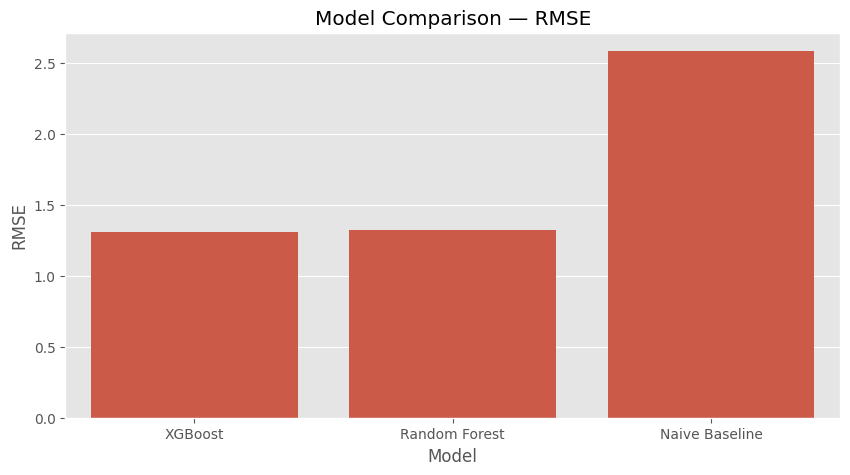

In [23]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results,
    x="Model",
    y="RMSE"
)

plt.title("Model Comparison — RMSE")
plt.ylabel("RMSE")
plt.xlabel("Model")

plt.show()

# 12. Best Model Selection

The model with the lowest RMSE is selected as the best-performing forecasting model.

In [24]:
best_model_name = results.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: XGBoost


In [25]:
if best_model_name == "XGBoost":
    best_model = xgb_model
    best_predictions = xgb_predictions

elif best_model_name == "Random Forest":
    best_model = rf_model
    best_predictions = rf_predictions

else:
    best_model = None
    best_predictions = baseline_predictions

print("Best model selected successfully.")

Best model selected successfully.


# 13. Feature Importance

Feature importance is analyzed to identify which variables have the strongest influence on demand predictions.

This provides both technical model interpretation and useful business insights.

In [26]:
if best_model is not None:

    importance_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": best_model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        "Importance",
        ascending=False
    ).reset_index(drop=True)

    importance_df.head(20)

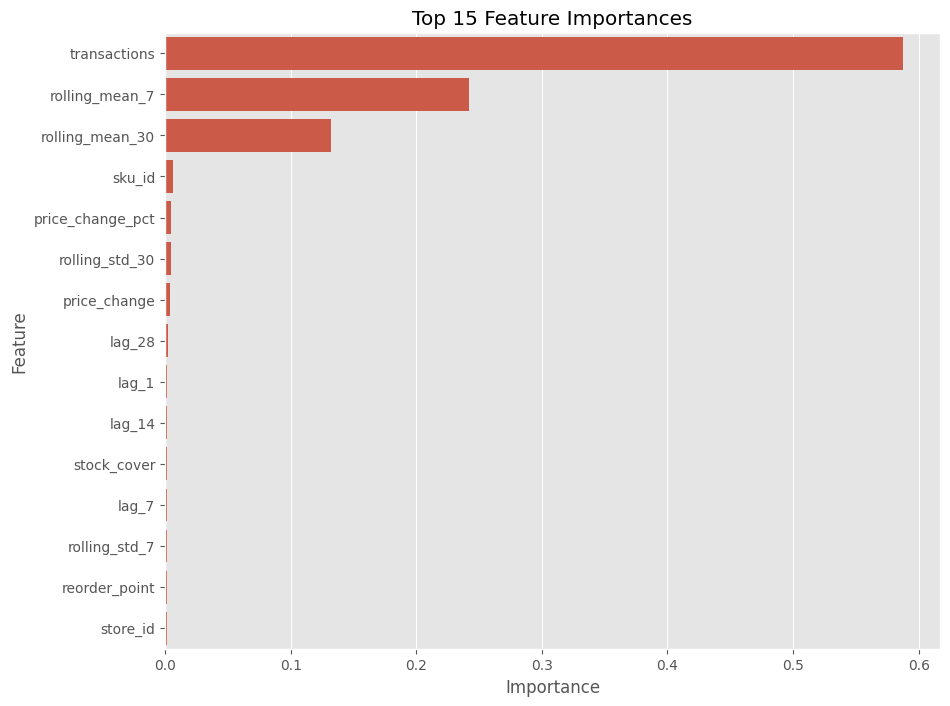

In [27]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# 14. Actual vs Predicted Demand

Actual demand is compared with model predictions to visually assess forecasting performance.

In [28]:
prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": best_predictions
})

prediction_df.head()

,Actual,Predicted
0,1,1.884329
1,6,3.739152
2,3,3.766144
3,2,1.913521
4,2,1.878026


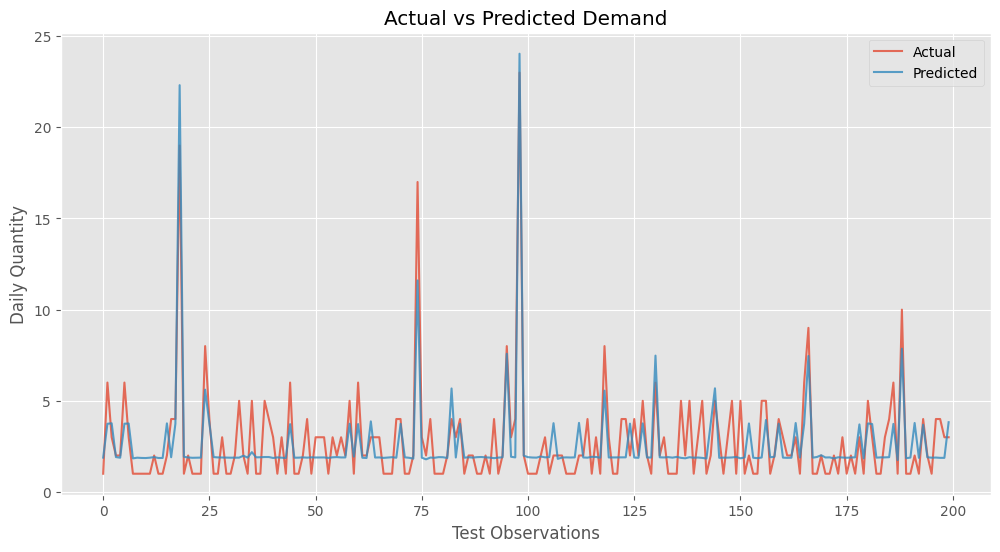

In [29]:
plt.figure(figsize=(12, 6))

plt.plot(
    prediction_df["Actual"].values[:200],
    label="Actual",
    alpha=0.8
)

plt.plot(
    prediction_df["Predicted"].values[:200],
    label="Predicted",
    alpha=0.8
)

plt.title("Actual vs Predicted Demand")
plt.xlabel("Test Observations")
plt.ylabel("Daily Quantity")

plt.legend()

plt.show()

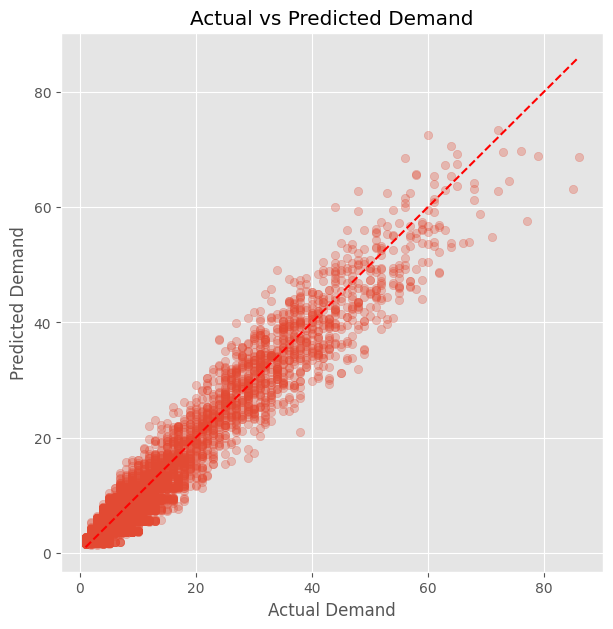

In [30]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.3
)

min_value = min(
    y_test.min(),
    best_predictions.min()
)

max_value = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand")

plt.show()

# 15. Forecast Results by Date

Predictions are combined with the original testing dates to analyze how well the model forecasts demand over time.

In [31]:
forecast_results = forecast_df.iloc[
    split_index:
].copy()

forecast_results["predicted_quantity"] = (
    best_predictions
)

forecast_results[
    [
        "date",
        "store_id",
        "sku_id",
        "daily_quantity",
        "predicted_quantity"
    ]
].head(20)

,date,store_id,sku_id,daily_quantity,predicted_quantity
698906,2025-07-02,ST24,SKU04710,1,1.884329
698907,2025-07-02,ST24,SKU04913,6,3.739152
698908,2025-07-02,ST25,SKU00002,3,3.766144
698909,2025-07-02,ST25,SKU00079,2,1.913521
698910,2025-07-02,ST25,SKU00169,2,1.878026
698911,2025-07-02,ST25,SKU00500,6,3.742833
698912,2025-07-02,ST25,SKU00953,3,3.754621
698913,2025-07-02,ST25,SKU01021,1,1.841223
698914,2025-07-02,ST25,SKU01418,1,1.878896
698915,2025-07-02,ST25,SKU02176,1,1.865652


In [32]:
daily_forecast = (
    forecast_results
    .groupby("date", as_index=False)
    .agg(
        actual_demand=("daily_quantity", "sum"),
        predicted_demand=("predicted_quantity", "sum")
    )
)

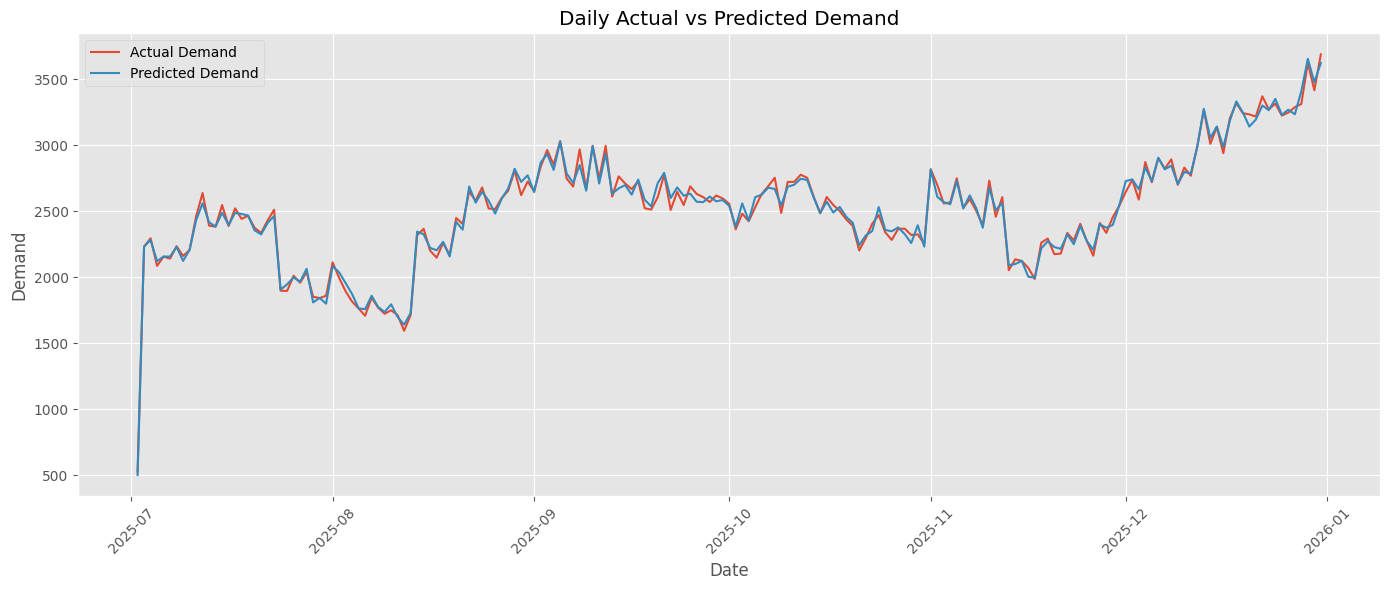

In [33]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_forecast["date"],
    daily_forecast["actual_demand"],
    label="Actual Demand"
)

plt.plot(
    daily_forecast["date"],
    daily_forecast["predicted_demand"],
    label="Predicted Demand"
)

plt.title("Daily Actual vs Predicted Demand")
plt.xlabel("Date")
plt.ylabel("Demand")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# 16. Business Insights

The forecasting model provides several potential business applications:

### 1. Inventory Planning

Accurate demand forecasts can help retailers determine appropriate stock levels and reduce the risk of stockouts.

### 2. Replenishment Decisions

Lag and rolling demand features can help identify products that require replenishment based on recent demand patterns.

### 3. Promotion Planning

Pricing and discount features allow the model to capture relationships between promotional activity and demand.

### 4. Seasonal Planning

Calendar features allow the model to identify recurring weekly, monthly, quarterly, and seasonal demand patterns.

### 5. Data-Driven Decision Making

The forecasting system can support inventory managers and retail planners by providing demand estimates for future periods.

# 17. Save Forecast Results

The final predictions are saved for downstream analysis and dashboard development.

In [34]:
forecast_results.to_csv(
    "/kaggle/working/forecast_predictions.csv",
    index=False
)

print("Forecast predictions saved successfully!")

Forecast predictions saved successfully!


In [35]:
if best_model is not None:

    joblib.dump(
        best_model,
        "/kaggle/working/best_forecasting_model.pkl"
    )

    print("Best forecasting model saved successfully!")

else:

    print(
        "Naive baseline was the best model. "
        "No machine learning model saved."
    )

Best forecasting model saved successfully!


In [36]:
model_summary = pd.DataFrame({
    "Best_Model": [best_model_name],
    "MAE": [results.iloc[0]["MAE"]],
    "RMSE": [results.iloc[0]["RMSE"]],
    "R2": [results.iloc[0]["R2"]]
})

model_summary

,Best_Model,MAE,RMSE,R2
0,XGBoost,0.998932,1.310529,0.854022


In [37]:
model_summary.to_csv(
    "/kaggle/working/model_results.csv",
    index=False
)

print("Model evaluation results saved successfully!")

Model evaluation results saved successfully!


In [38]:
# ===========================================
# Final Model Output Export
# ===========================================

print("Available variables:")
print("forecast_results:", "forecast_results" in globals())
print("predictions:", "predictions" in globals())
print("best_model:", "best_model" in globals())
print("results:", "results" in globals())
print("best_model_name:", "best_model_name" in globals())

forecast_results.to_csv(
    "/kaggle/working/forecast_predictions.csv",
    index=False
)

results.to_csv(
    "/kaggle/working/model_results.csv",
    index=False
)

print("Forecast predictions saved successfully!")
print("Model results saved successfully!")

Available variables:
forecast_results: True
predictions: False
best_model: True
results: True
best_model_name: True
Forecast predictions saved successfully!
Model results saved successfully!


In [39]:
import os

print("Files in /kaggle/working:")

for file in os.listdir("/kaggle/working"):
    print(file)

Files in /kaggle/working:
forecast_predictions.csv
__notebook__.ipynb
model_results.csv
best_forecasting_model.pkl
